# 01 — Data Understanding dan Exploratory Data Analysis (EDA)

**Project:** NutriSmart AI  
**Dataset utama:** `ObesityDataSet_raw_and_data_sinthetic.csv`

## Tujuan notebook

Notebook ini digunakan untuk:

1. Memahami sumber, ukuran, dan struktur dataset.
2. Memahami arti setiap variabel.
3. Memeriksa kualitas data: missing value, duplikat, tipe data, dan rentang nilai.
4. Mengamati distribusi fitur numerik dan kategorikal.
5. Mengamati distribusi target `NObeyesdad`.
6. Mengidentifikasi hubungan awal antara pola hidup dan tingkat obesitas.
7. Menentukan keputusan awal sebelum tahap preprocessing dan modeling.

> **Batas notebook:** Notebook ini belum melakukan encoding, pembagian train-test, training model, atau pemilihan model. Semua proses tersebut dilakukan pada notebook berikutnya.


## 1. Informasi sumber dataset

Dataset berasal dari **UCI Machine Learning Repository** dengan judul:

**Estimation of Obesity Levels Based on Eating Habits and Physical Condition**

Dataset memuat data individu dari Meksiko, Peru, dan Kolombia. Dataset terdiri dari 2.111 observasi dan 17 kolom. Menurut dokumentasi sumber, sekitar 23% data dikumpulkan melalui platform web dan sekitar 77% data dibentuk secara sintetik menggunakan Weka dan SMOTE.

Sumber:

- [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)
- [Artikel pengantar dataset](https://doi.org/10.1016/j.dib.2019.104344)

### Implikasi bagi project

- Dataset sesuai untuk eksperimen klasifikasi.
- Dataset tidak secara khusus merepresentasikan populasi Indonesia.
- Sebagian besar data bersifat sintetik sehingga performa model harus ditafsirkan secara hati-hati.
- Hasil aplikasi hanya digunakan sebagai **skrining berbasis data**, bukan diagnosis medis.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print("Library berhasil dimuat.")


Library berhasil dimuat.


## 2. Menentukan lokasi project dan membaca dataset

Kode berikut dibuat agar notebook tetap dapat dijalankan ketika Jupyter dibuka dari:

- folder utama project; atau
- folder `notebooks/`.


In [2]:
DATASET_FILENAME = "ObesityDataSet_raw_and_data_sinthetic.csv"

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in candidate_roots
        if (path / "data" / "raw" / DATASET_FILENAME).exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Pastikan file berada di "
        "data/raw/ObesityDataSet_raw_and_data_sinthetic.csv"
    )

DATA_PATH = PROJECT_ROOT / "data" / "raw" / DATASET_FILENAME

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset path : {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Dataset berhasil dibaca.")


Project root : C:\Projects\nutrismart-ai
Dataset path : C:\Projects\nutrismart-ai\data\raw\ObesityDataSet_raw_and_data_sinthetic.csv
Dataset berhasil dibaca.


In [3]:
display(df.head())


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000,1.620,64.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,0.000,1.000,no,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,yes,no,3.000,3.000,Sometimes,yes,3.000,yes,3.000,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,2.000,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,no,no,3.000,3.000,Sometimes,no,2.000,no,2.000,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,no,no,2.000,1.000,Sometimes,no,2.000,no,0.000,0.000,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Data dictionary

Kelompok variabel pada dataset:

- **Karakteristik individu:** `Gender`, `Age`, `Height`, `Weight`, dan riwayat keluarga.
- **Pola makan:** `FAVC`, `FCVC`, `NCP`, `CAEC`, `CH2O`, dan `CALC`.
- **Aktivitas dan perilaku:** `SCC`, `FAF`, `TUE`, `SMOKE`, dan `MTRANS`.
- **Target:** `NObeyesdad`.

Sebagian fitur seperti `FCVC`, `CH2O`, `FAF`, dan `TUE` memiliki rentang skor tertentu. Karena sebagian besar data dibuat secara sintetik, dataset juga mengandung nilai desimal di antara skor kategorinya.


In [4]:
data_dictionary = pd.DataFrame(
    [
        ("Gender", "Kategorikal", "Jenis kelamin", "Male, Female"),
        ("Age", "Numerik", "Usia individu dalam tahun", "14–61 pada dataset"),
        ("Height", "Numerik", "Tinggi badan dalam meter", "Nilai kontinu"),
        ("Weight", "Numerik", "Berat badan dalam kilogram", "Nilai kontinu"),
        (
            "family_history_with_overweight",
            "Kategorikal",
            "Riwayat keluarga dengan kelebihan berat badan",
            "yes, no",
        ),
        (
            "FAVC",
            "Kategorikal",
            "Sering mengonsumsi makanan tinggi kalori",
            "yes, no",
        ),
        (
            "FCVC",
            "Numerik/ordinal",
            "Frekuensi konsumsi sayuran",
            "Skala 1–3",
        ),
        (
            "NCP",
            "Numerik/ordinal",
            "Jumlah makanan utama",
            "Skala 1–4",
        ),
        (
            "CAEC",
            "Kategorikal ordinal",
            "Konsumsi makanan di antara waktu makan",
            "no, Sometimes, Frequently, Always",
        ),
        ("SMOKE", "Kategorikal", "Kebiasaan merokok", "yes, no"),
        (
            "CH2O",
            "Numerik/ordinal",
            "Konsumsi air harian",
            "Skala 1–3",
        ),
        (
            "SCC",
            "Kategorikal",
            "Kebiasaan memantau konsumsi kalori",
            "yes, no",
        ),
        (
            "FAF",
            "Numerik/ordinal",
            "Frekuensi aktivitas fisik",
            "Skala 0–3",
        ),
        (
            "TUE",
            "Numerik/ordinal",
            "Waktu menggunakan perangkat teknologi",
            "Skala 0–2",
        ),
        (
            "CALC",
            "Kategorikal ordinal",
            "Konsumsi alkohol",
            "no, Sometimes, Frequently, Always",
        ),
        (
            "MTRANS",
            "Kategorikal",
            "Moda transportasi utama",
            "Automobile, Bike, Motorbike, Public Transportation, Walking",
        ),
        (
            "NObeyesdad",
            "Kategorikal target",
            "Tingkat/kategori obesitas",
            "7 kelas",
        ),
    ],
    columns=["Kolom", "Tipe Konseptual", "Deskripsi", "Nilai/Rentang"],
)

display(data_dictionary)


,Kolom,Tipe Konseptual,Deskripsi,Nilai/Rentang
0,Gender,Kategorikal,Jenis kelamin,"Male, Female"
1,Age,Numerik,Usia individu dalam tahun,14–61 pada dataset
2,Height,Numerik,Tinggi badan dalam meter,Nilai kontinu
3,Weight,Numerik,Berat badan dalam kilogram,Nilai kontinu
4,family_history_with_overweight,Kategorikal,Riwayat keluarga dengan kelebihan berat badan,"yes, no"
5,FAVC,Kategorikal,Sering mengonsumsi makanan tinggi kalori,"yes, no"
6,FCVC,Numerik/ordinal,Frekuensi konsumsi sayuran,Skala 1–3
7,NCP,Numerik/ordinal,Jumlah makanan utama,Skala 1–4
8,CAEC,Kategorikal ordinal,Konsumsi makanan di antara waktu makan,"no, Sometimes, Frequently, Always"
9,SMOKE,Kategorikal,Kebiasaan merokok,"yes, no"


## 4. Struktur dasar dataset

Bagian ini memeriksa:

- jumlah baris dan kolom;
- nama kolom;
- tipe data;
- penggunaan memori;
- jumlah nilai unik.


In [5]:
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")


Jumlah baris : 2,111
Jumlah kolom : 17


In [6]:
print("Daftar kolom:")
for index, column in enumerate(df.columns, start=1):
    print(f"{index:>2}. {column}")


Daftar kolom:
 1. Gender
 2. Age
 3. Height
 4. Weight
 5. family_history_with_overweight
 6. FAVC
 7. FCVC
 8. NCP
 9. CAEC
10. SMOKE
11. CH2O
12. SCC
13. FAF
14. TUE
15. CALC
16. MTRANS
17. NObeyesdad


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [8]:
column_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(),
    }
).sort_values(["dtype", "unique_values"])

display(column_summary)


,dtype,non_null,missing,missing_pct,unique_values
NCP,float64,2111,0,0.000,635
FCVC,float64,2111,0,0.000,810
TUE,float64,2111,0,0.000,1129
FAF,float64,2111,0,0.000,1190
CH2O,float64,2111,0,0.000,1268
Age,float64,2111,0,0.000,1402
Weight,float64,2111,0,0.000,1525
Height,float64,2111,0,0.000,1574
Gender,str,2111,0,0.000,2
family_history_with_overweight,str,2111,0,0.000,2


### Interpretasi awal tipe data

Kolom `Age`, `FCVC`, `NCP`, `CH2O`, `FAF`, dan `TUE` disimpan sebagai `float64`. Nilai tersebut tidak selalu bulat karena sebagian data dibentuk secara sintetik.

Pada tahap preprocessing berikutnya, kita tidak boleh langsung membulatkan nilai tanpa alasan. Nilai dapat dipertahankan sebagai numerik selama sesuai dengan rentang dokumentasinya.


In [9]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Kolom numerik:")
print(numeric_columns)

print("\nKolom kategorikal:")
print(categorical_columns)


Kolom numerik:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Kolom kategorikal:
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


## 5. Pemeriksaan kualitas data

Pemeriksaan meliputi:

1. Missing value.
2. Duplikat.
3. Nilai di luar rentang yang terdokumentasi.
4. Konsistensi nilai kategorikal.


In [10]:
missing_summary = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_percentage": (df.isna().mean() * 100).round(2),
        }
    )
    .sort_values("missing_count", ascending=False)
)

display(missing_summary)
print(f"Total missing value: {int(df.isna().sum().sum())}")


,missing_count,missing_percentage
Gender,0,0.000
Age,0,0.000
Height,0,0.000
Weight,0,0.000
family_history_with_overweight,0,0.000
FAVC,0,0.000
FCVC,0,0.000
NCP,0,0.000
CAEC,0,0.000
SMOKE,0,0.000


Total missing value: 0


In [11]:
duplicate_count = int(df.duplicated().sum())
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Jumlah baris duplikat penuh : {duplicate_count}")
print(f"Persentase duplikat         : {duplicate_percentage:.2f}%")

if duplicate_count > 0:
    print("\nContoh baris yang memiliki duplikat:")
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(
        by=list(df.columns)
    )
    display(duplicate_rows.head(10))


Jumlah baris duplikat penuh : 24
Persentase duplikat         : 1.14%

Contoh baris yang memiliki duplikat:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
295,Female,16.000,1.660,58.000,no,no,2.000,1.000,Sometimes,no,1.000,no,0.000,1.000,no,Walking,Normal_Weight
309,Female,16.000,1.660,58.000,no,no,2.000,1.000,Sometimes,no,1.000,no,0.000,1.000,no,Walking,Normal_Weight
282,Female,18.000,1.620,55.000,yes,yes,2.000,3.000,Frequently,no,1.000,no,1.000,1.000,no,Public_Transportation,Normal_Weight
460,Female,18.000,1.620,55.000,yes,yes,2.000,3.000,Frequently,no,1.000,no,1.000,1.000,no,Public_Transportation,Normal_Weight
97,Female,21.000,1.520,42.000,no,no,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.000,1.520,42.000,no,no,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
523,Female,21.000,1.520,42.000,no,yes,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
527,Female,21.000,1.520,42.000,no,yes,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
659,Female,21.000,1.520,42.000,no,yes,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
663,Female,21.000,1.520,42.000,no,yes,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight


### Keputusan awal terkait duplikat

Baris duplikat penuh sebaiknya dihapus pada notebook preprocessing **sebelum** pembagian data training dan testing. Hal ini mengurangi risiko observasi identik muncul pada kedua bagian data dan membuat performa model terlihat terlalu tinggi.

Dataset mentah pada folder `data/raw/` tidak diubah pada notebook ini.


In [12]:
documented_ranges = {
    "FCVC": (1, 3),
    "NCP": (1, 4),
    "CH2O": (1, 3),
    "FAF": (0, 3),
    "TUE": (0, 2),
}

range_checks = []

for column, (minimum, maximum) in documented_ranges.items():
    invalid_count = int((~df[column].between(minimum, maximum)).sum())
    range_checks.append(
        {
            "column": column,
            "documented_min": minimum,
            "observed_min": df[column].min(),
            "documented_max": maximum,
            "observed_max": df[column].max(),
            "invalid_count": invalid_count,
        }
    )

range_check_df = pd.DataFrame(range_checks)
display(range_check_df)


,column,documented_min,observed_min,documented_max,observed_max,invalid_count
0,FCVC,1,1.000,3,3.000,0
1,NCP,1,1.000,4,4.000,0
2,CH2O,1,1.000,3,3.000,0
3,FAF,0,0.000,3,3.000,0
4,TUE,0,0.000,2,2.000,0


In [13]:
allowed_categories = {
    "Gender": {"Male", "Female"},
    "family_history_with_overweight": {"yes", "no"},
    "FAVC": {"yes", "no"},
    "CAEC": {"no", "Sometimes", "Frequently", "Always"},
    "SMOKE": {"yes", "no"},
    "SCC": {"yes", "no"},
    "CALC": {"no", "Sometimes", "Frequently", "Always"},
    "MTRANS": {
        "Automobile",
        "Bike",
        "Motorbike",
        "Public_Transportation",
        "Walking",
    },
}

category_checks = []

for column, allowed_values in allowed_categories.items():
    observed_values = set(df[column].dropna().unique())
    unexpected_values = sorted(observed_values - allowed_values)

    category_checks.append(
        {
            "column": column,
            "observed_unique": len(observed_values),
            "unexpected_values": unexpected_values,
            "is_valid": len(unexpected_values) == 0,
        }
    )

display(pd.DataFrame(category_checks))


,column,observed_unique,unexpected_values,is_valid
0,Gender,2,[],True
1,family_history_with_overweight,2,[],True
2,FAVC,2,[],True
3,CAEC,4,[],True
4,SMOKE,2,[],True
5,SCC,2,[],True
6,CALC,4,[],True
7,MTRANS,5,[],True


## 6. Statistik deskriptif fitur numerik

Statistik ini membantu memahami:

- nilai minimum dan maksimum;
- rata-rata dan median;
- penyebaran data;
- kemungkinan nilai ekstrem;
- karakteristik skala setiap variabel.


In [14]:
numeric_summary = df[numeric_columns].describe().T
numeric_summary["median"] = df[numeric_columns].median()
numeric_summary["skewness"] = df[numeric_columns].skew()
numeric_summary = numeric_summary[
    ["count", "mean", "std", "min", "25%", "median", "75%", "max", "skewness"]
]

display(numeric_summary)


,count,mean,std,min,25%,median,75%,max,skewness
Age,"2,111.000",24.313,6.346,14.000,19.947,22.778,26.000,61.000,1.529
Height,"2,111.000",1.702,0.093,1.450,1.630,1.700,1.768,1.980,-0.013
Weight,"2,111.000",86.586,26.191,39.000,65.473,83.000,107.431,173.000,0.255
FCVC,"2,111.000",2.419,0.534,1.000,2.000,2.386,3.000,3.000,-0.433
NCP,"2,111.000",2.686,0.778,1.000,2.659,3.000,3.000,4.000,-1.107
CH2O,"2,111.000",2.008,0.613,1.000,1.585,2.000,2.477,3.000,-0.105
FAF,"2,111.000",1.010,0.851,0.000,0.125,1.000,1.667,3.000,0.498
TUE,"2,111.000",0.658,0.609,0.000,0.000,0.625,1.000,2.000,0.619


In [15]:
decimal_value_summary = []

for column in numeric_columns:
    decimal_percentage = ((df[column] % 1) != 0).mean() * 100
    decimal_value_summary.append(
        {
            "column": column,
            "percentage_non_integer": round(decimal_percentage, 2),
        }
    )

display(pd.DataFrame(decimal_value_summary))


,column,percentage_non_integer
0,Age,65.140
1,Height,100.000
2,Weight,68.830
3,FCVC,39.130
4,NCP,30.320
5,CH2O,61.110
6,FAF,57.220
7,TUE,54.620


### Catatan mengenai nilai desimal

Nilai desimal pada variabel yang secara konseptual berupa skala ordinal merupakan salah satu karakteristik data sintetik. Pada tahap awal, nilai tersebut akan tetap diperlakukan sebagai numerik.

Kita akan mengevaluasi kembali keputusan tersebut pada notebook preprocessing agar bentuk input aplikasi tetap mudah dipahami pengguna.


## 7. Distribusi fitur numerik

Setiap grafik dibuat terpisah agar mudah dibaca. Grafik histogram digunakan untuk melihat bentuk distribusi, sedangkan boxplot membantu melihat penyebaran dan nilai ekstrem.


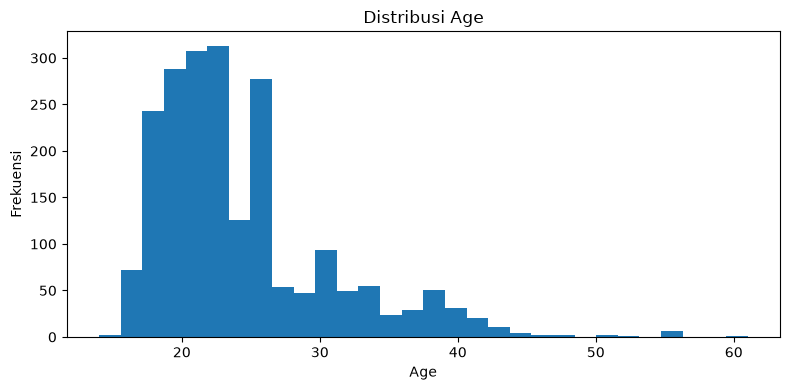

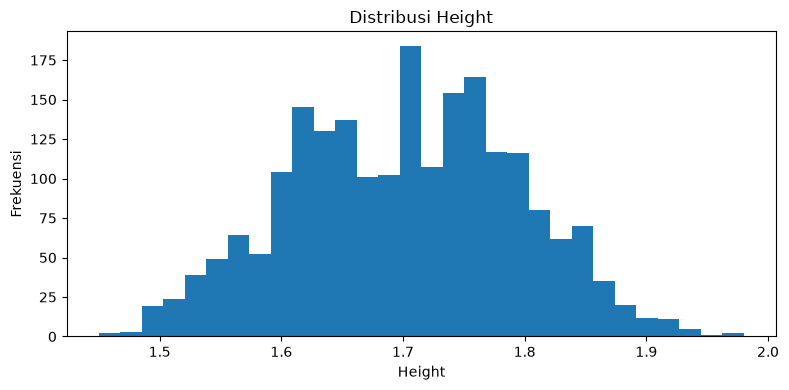

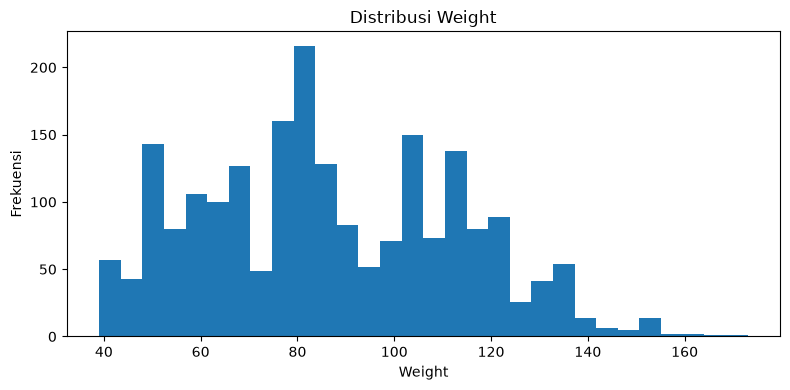

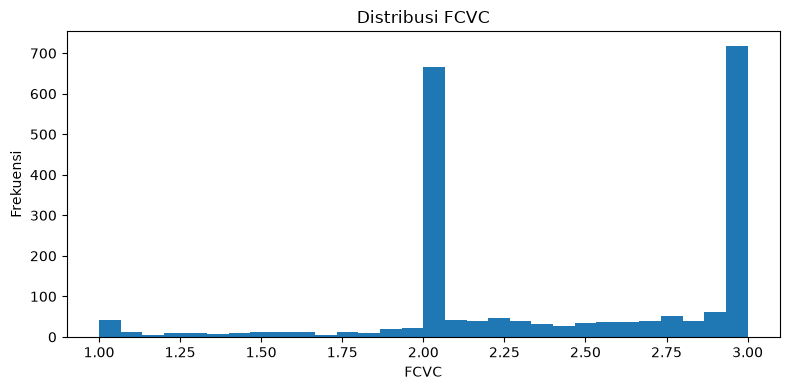

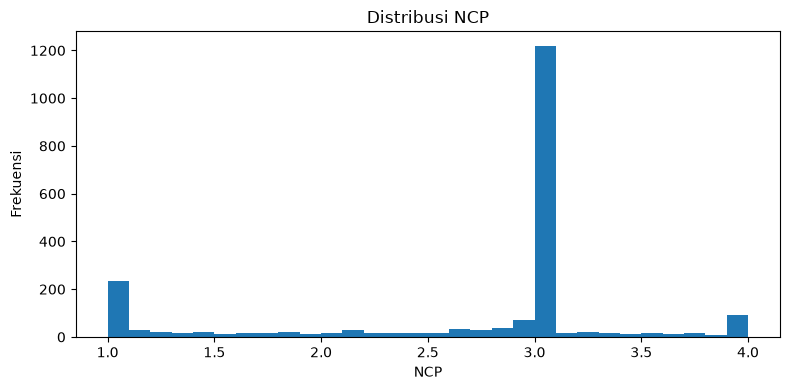

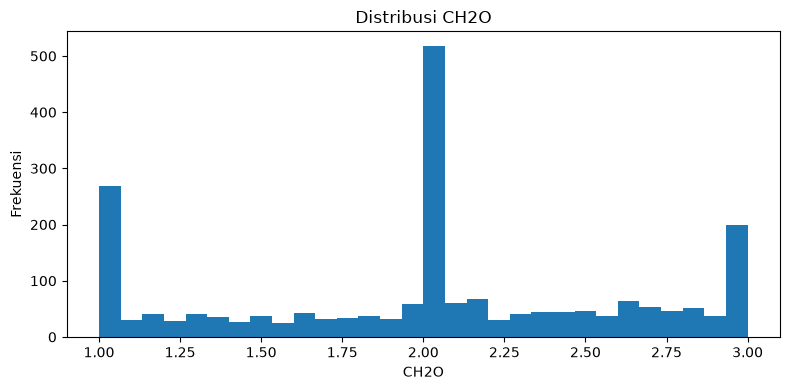

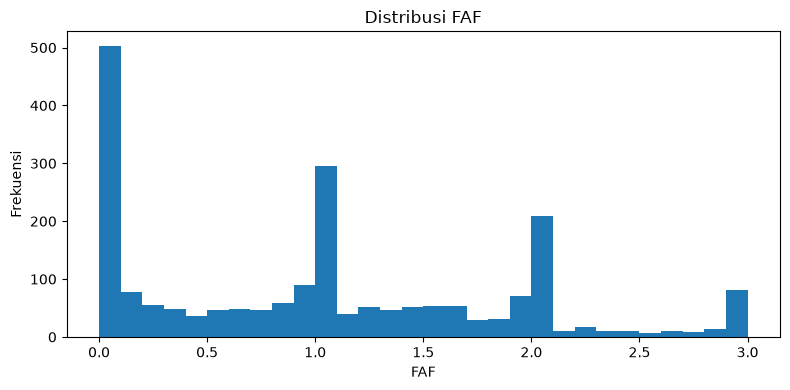

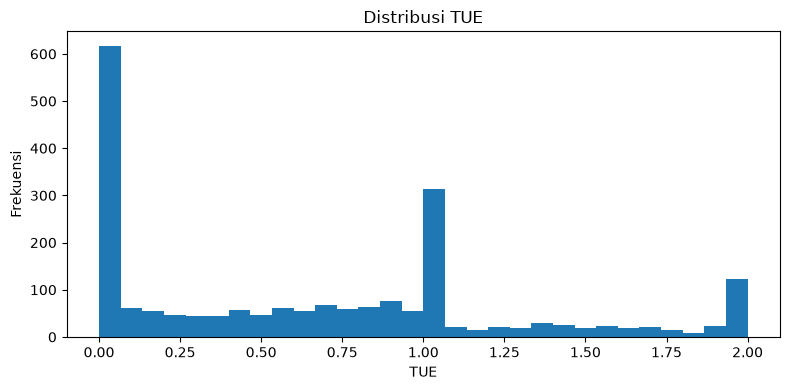

In [16]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribusi {column}")
    plt.xlabel(column)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()


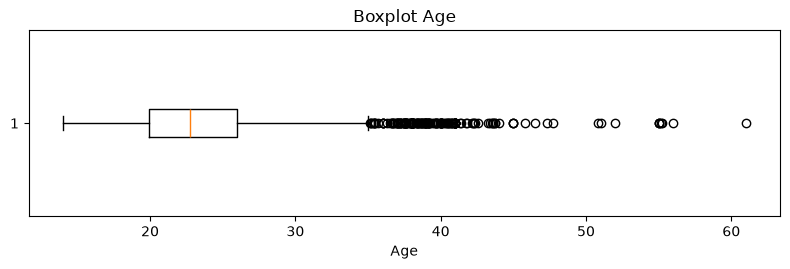

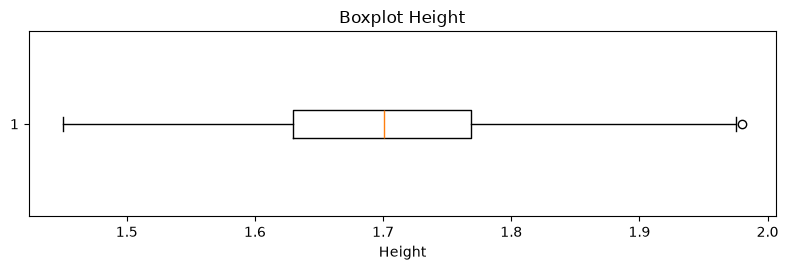

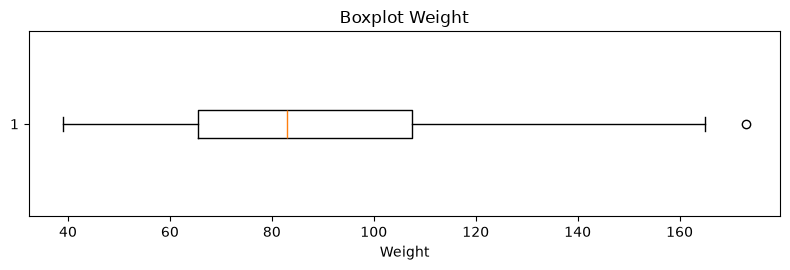

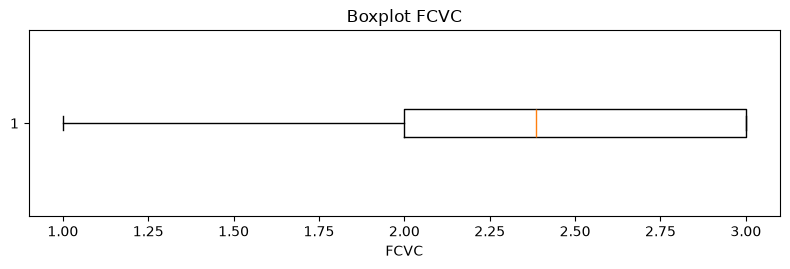

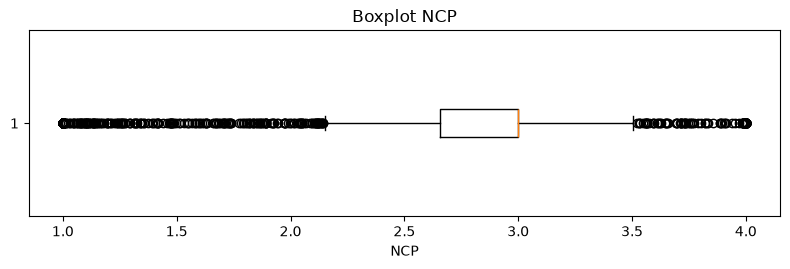

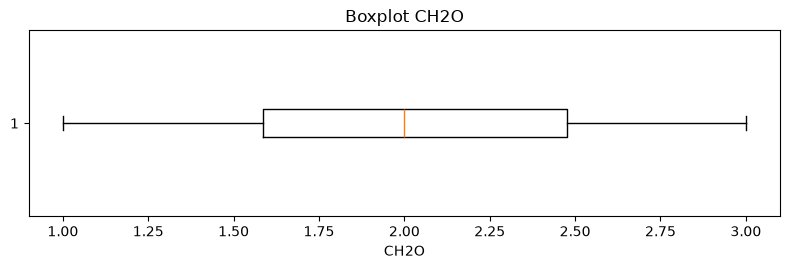

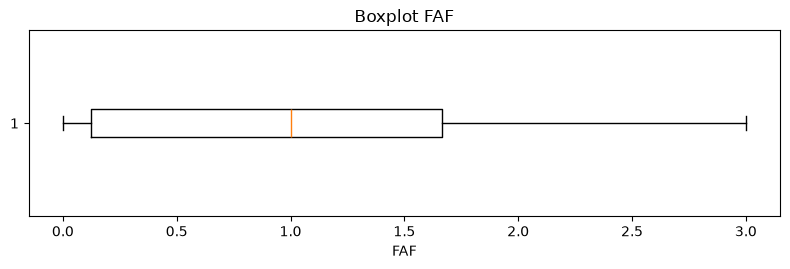

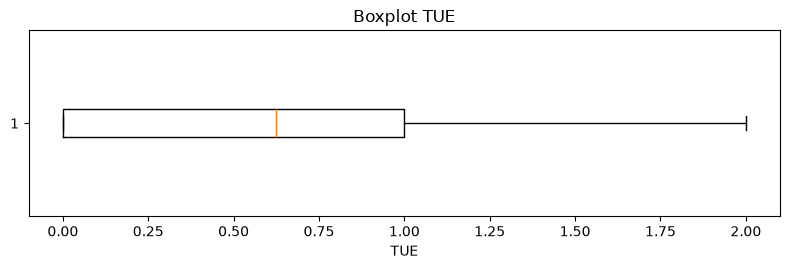

In [17]:
for column in numeric_columns:
    plt.figure(figsize=(8, 2.8))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Boxplot {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()


## 8. Distribusi fitur kategorikal

Bagian ini menampilkan jumlah dan proporsi setiap kategori.



=== Gender ===


,count,percentage
Gender,,
Male,1068,50.590
Female,1043,49.410


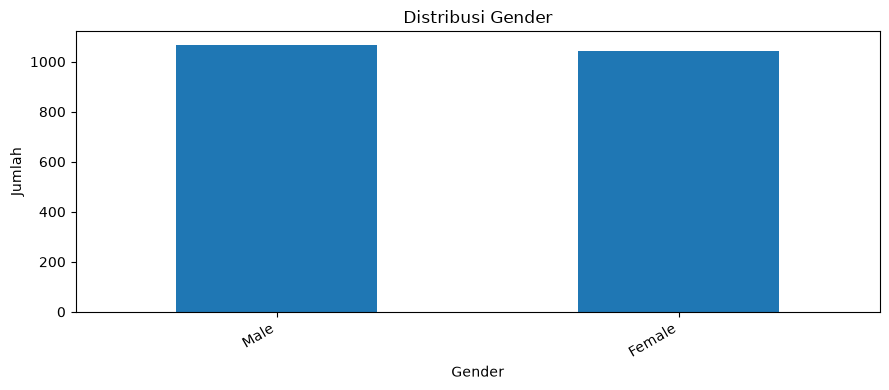


=== family_history_with_overweight ===


,count,percentage
family_history_with_overweight,,
yes,1726,81.760
no,385,18.240


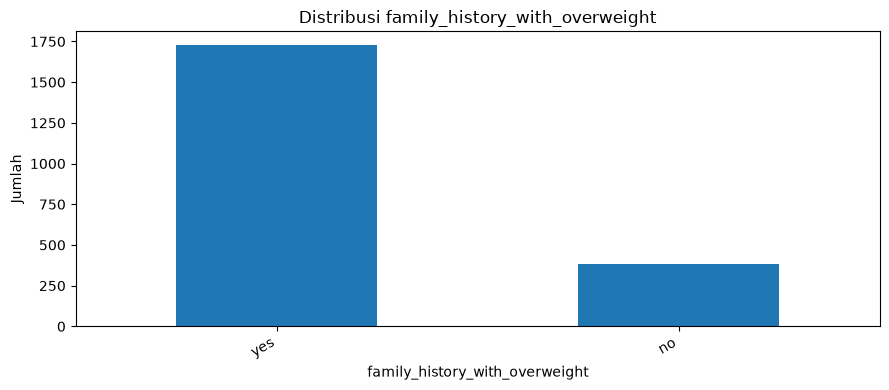


=== FAVC ===


,count,percentage
FAVC,,
yes,1866,88.390
no,245,11.610


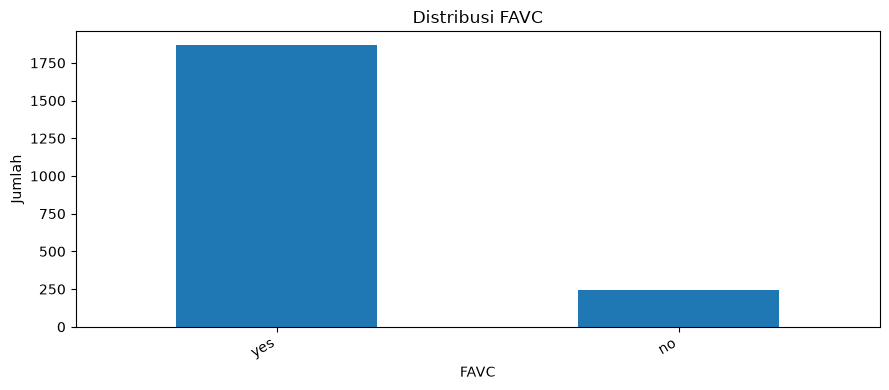


=== CAEC ===


,count,percentage
CAEC,,
Sometimes,1765,83.610
Frequently,242,11.460
Always,53,2.510
no,51,2.420


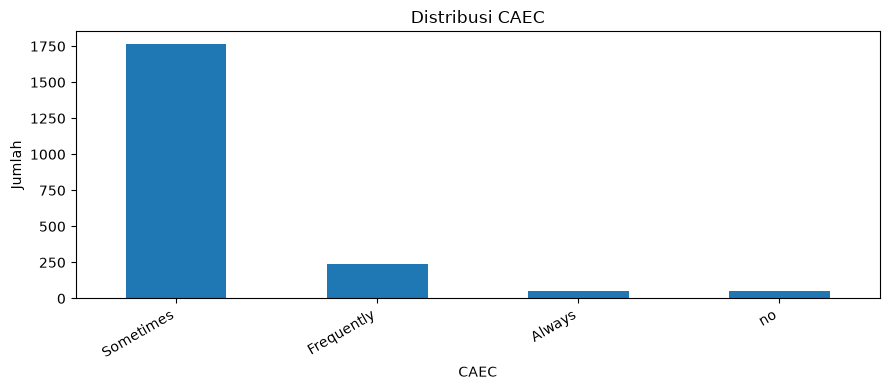


=== SMOKE ===


,count,percentage
SMOKE,,
no,2067,97.920
yes,44,2.080


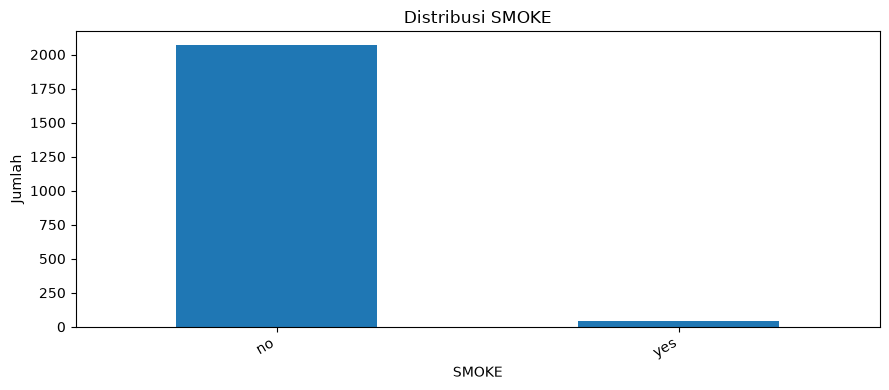


=== SCC ===


,count,percentage
SCC,,
no,2015,95.450
yes,96,4.550


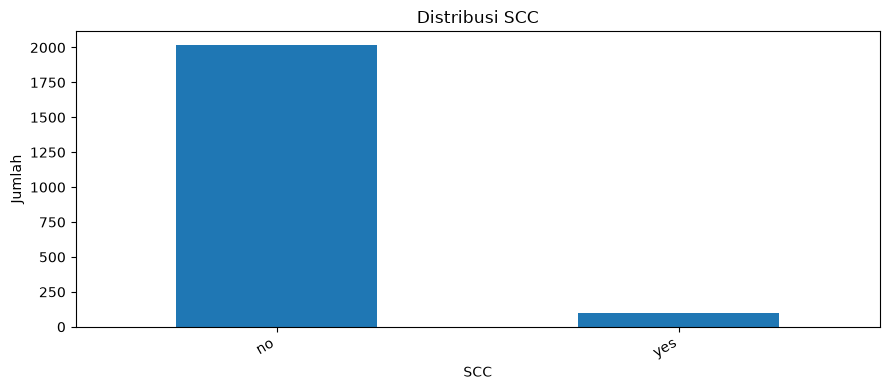


=== CALC ===


,count,percentage
CALC,,
Sometimes,1401,66.370
no,639,30.270
Frequently,70,3.320
Always,1,0.050


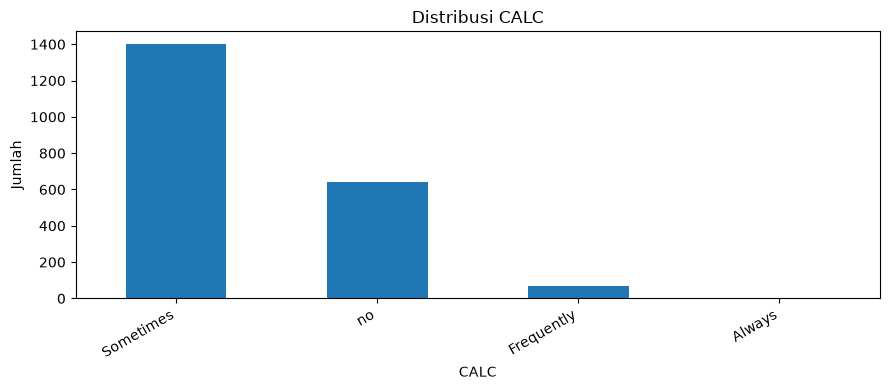


=== MTRANS ===


,count,percentage
MTRANS,,
Public_Transportation,1580,74.850
Automobile,457,21.650
Walking,56,2.650
Motorbike,11,0.520
Bike,7,0.330


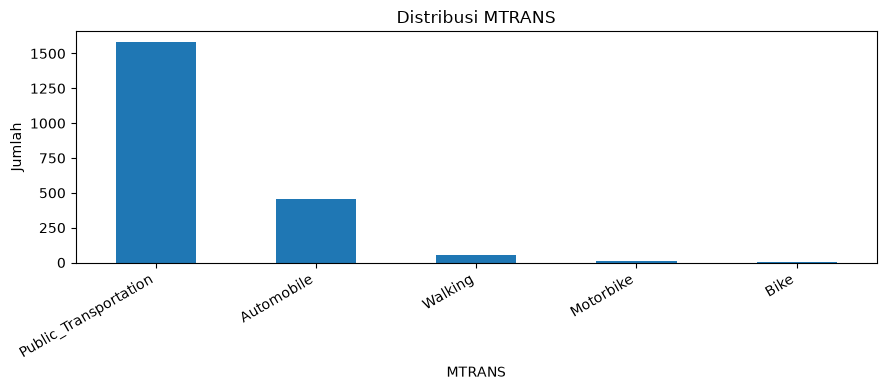

In [18]:
categorical_feature_columns = [
    column for column in categorical_columns if column != "NObeyesdad"
]

for column in categorical_feature_columns:
    counts = df[column].value_counts(dropna=False)
    percentages = (df[column].value_counts(normalize=True, dropna=False) * 100).round(2)

    summary = pd.DataFrame(
        {
            "count": counts,
            "percentage": percentages,
        }
    )

    print(f"\n=== {column} ===")
    display(summary)

    plt.figure(figsize=(9, 4))
    counts.plot(kind="bar")
    plt.title(f"Distribusi {column}")
    plt.xlabel(column)
    plt.ylabel("Jumlah")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


### Hal yang perlu diperhatikan

Beberapa kategori memiliki jumlah sangat kecil, misalnya:

- pengguna yang merokok;
- pengguna yang memantau kalori;
- transportasi `Bike` dan `Motorbike`;
- konsumsi alkohol `Always`.

Ketidakseimbangan kategori fitur perlu diperhatikan karena kategori yang sangat jarang dapat sulit dipelajari oleh model.


## 9. Distribusi target asli: `NObeyesdad`

Target asli memiliki tujuh kelas:

1. `Insufficient_Weight`
2. `Normal_Weight`
3. `Overweight_Level_I`
4. `Overweight_Level_II`
5. `Obesity_Type_I`
6. `Obesity_Type_II`
7. `Obesity_Type_III`


,count,percentage
NObeyesdad,,
Insufficient_Weight,272,12.880
Normal_Weight,287,13.600
Overweight_Level_I,290,13.740
Overweight_Level_II,290,13.740
Obesity_Type_I,351,16.630
Obesity_Type_II,297,14.070
Obesity_Type_III,324,15.350


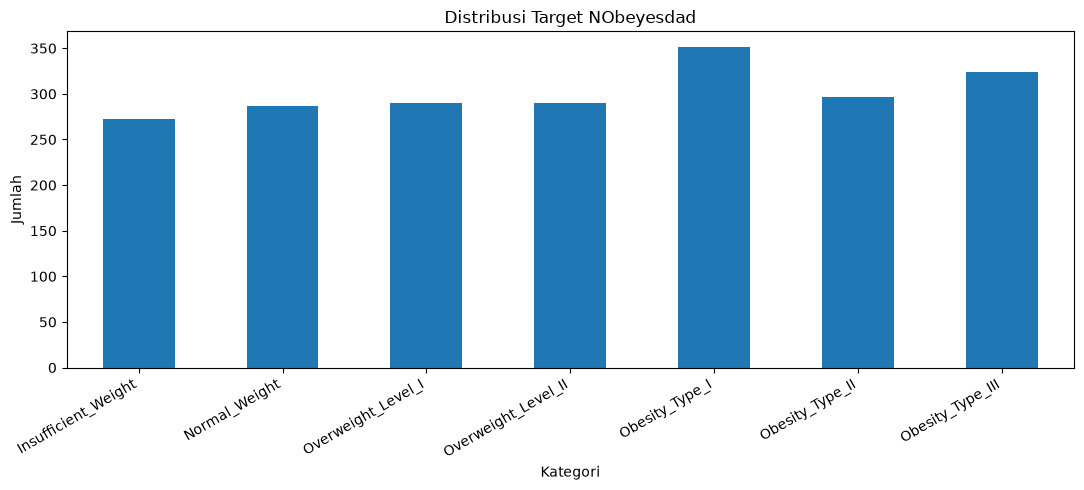

In [19]:
target_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

target_counts = df["NObeyesdad"].value_counts().reindex(target_order)
target_percentages = (
    df["NObeyesdad"].value_counts(normalize=True).reindex(target_order) * 100
).round(2)

target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "percentage": target_percentages,
    }
)

display(target_summary)

plt.figure(figsize=(11, 5))
target_counts.plot(kind="bar")
plt.title("Distribusi Target NObeyesdad")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [20]:
largest_class = target_counts.max()
smallest_class = target_counts.min()
imbalance_ratio = largest_class / smallest_class

print(f"Kelas terbesar : {target_counts.idxmax()} ({largest_class})")
print(f"Kelas terkecil : {target_counts.idxmin()} ({smallest_class})")
print(f"Rasio kelas terbesar terhadap terkecil: {imbalance_ratio:.2f}")


Kelas terbesar : Obesity_Type_I (351)
Kelas terkecil : Insufficient_Weight (272)
Rasio kelas terbesar terhadap terkecil: 1.29


### Interpretasi distribusi target

Tujuh kelas target relatif seimbang. Namun, hal tersebut tidak berarti kita boleh melewatkan evaluasi per kelas.

Pada project NutriSmart AI, target nantinya direncanakan menjadi klasifikasi biner:

- **Non-Obesity**
- **Obesity**

Pembuatan target biner akan dilakukan secara formal pada notebook preprocessing.


## 10. Perhitungan BMI hanya untuk kepentingan EDA

BMI dihitung untuk memahami hubungan antara `Height`, `Weight`, dan label target.

> **Penting:** BMI, tinggi, dan berat badan tidak direncanakan sebagai fitur utama model risiko pola hidup. Jika dimasukkan, model dapat menebak label terutama dari kondisi tubuh, bukan dari pola makan dan aktivitas.


In [21]:
df_eda = df.copy()
df_eda["BMI_EDA"] = df_eda["Weight"] / (df_eda["Height"] ** 2)

display(df_eda["BMI_EDA"].describe().to_frame("BMI_EDA"))


,BMI_EDA
count,"2,111.000"
mean,29.700
std,8.011
min,12.999
25%,24.326
50%,28.719
75%,36.017
max,50.812


In [22]:
bmi_by_target = (
    df_eda.groupby("NObeyesdad", observed=False)["BMI_EDA"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(target_order)
)

display(bmi_by_target)


,count,mean,median,min,max
NObeyesdad,,,,,
Insufficient_Weight,272,17.404,17.547,12.999,19.082
Normal_Weight,287,22.014,22.145,18.491,24.913
Overweight_Level_I,290,25.991,25.978,22.827,28.770
Overweight_Level_II,290,28.215,28.152,25.714,30.363
Obesity_Type_I,351,32.256,32.200,29.912,35.171
Obesity_Type_II,297,36.723,36.418,34.049,39.787
Obesity_Type_III,324,42.274,41.943,36.774,50.812


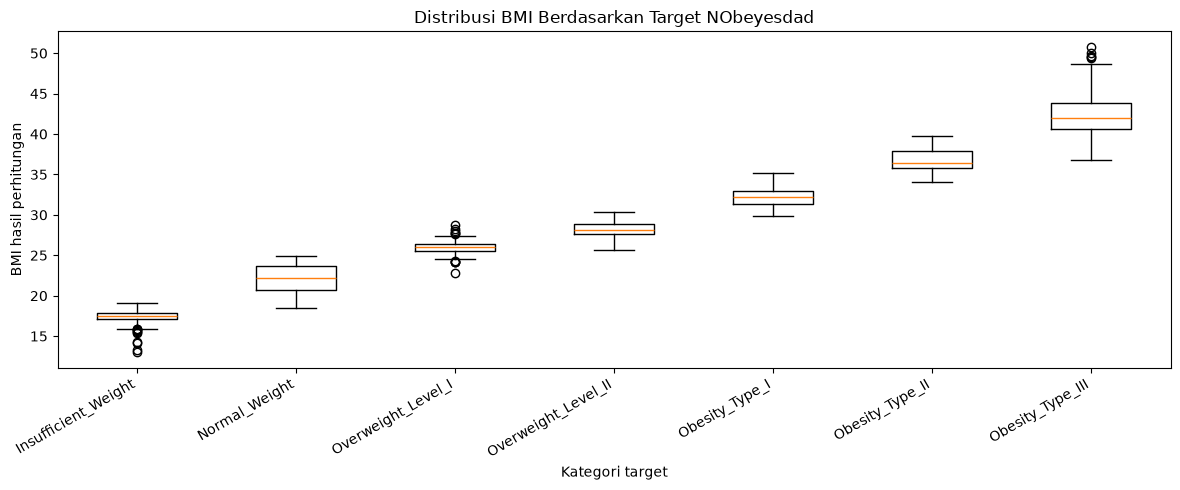

In [24]:
bmi_group_data = [
    df_eda.loc[
        df_eda["NObeyesdad"] == category,
        "BMI_EDA"
    ].dropna()
    for category in target_order
]

plt.figure(figsize=(12, 5))

plt.boxplot(
    bmi_group_data,
    tick_labels=target_order,
    vert=True
)

plt.title("Distribusi BMI Berdasarkan Target NObeyesdad")
plt.xlabel("Kategori target")
plt.ylabel("BMI hasil perhitungan")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Kesimpulan penting mengenai potensi leakage

Perbedaan BMI antar-kelas sangat jelas karena target memang berhubungan langsung dengan tinggi dan berat badan. Apabila `Height`, `Weight`, atau BMI digunakan sebagai prediktor, performa model dapat menjadi sangat tinggi tetapi tidak lagi menjawab tujuan utama project.

Untuk menjaga konsep:

- **BMI:** menjelaskan status tubuh saat ini.
- **Model AI:** menilai pola hidup berdasarkan pola makan dan aktivitas.


## 11. Hubungan fitur numerik dengan target asli

Tabel berikut menampilkan rata-rata fitur numerik pada setiap kategori target.


In [25]:
numeric_by_target = (
    df_eda.groupby("NObeyesdad", observed=False)[numeric_columns + ["BMI_EDA"]]
    .mean()
    .reindex(target_order)
)

display(numeric_by_target)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI_EDA
NObeyesdad,,,,,,,,,
Insufficient_Weight,19.783,1.691,49.906,2.481,2.914,1.871,1.250,0.839,17.404
Normal_Weight,21.739,1.677,62.155,2.334,2.739,1.850,1.247,0.676,22.014
Overweight_Level_I,23.418,1.688,74.267,2.265,2.504,2.059,1.057,0.613,25.991
Overweight_Level_II,26.997,1.704,82.085,2.261,2.496,2.025,0.958,0.697,28.215
Obesity_Type_I,25.885,1.694,92.870,2.186,2.432,2.112,0.987,0.677,32.256
Obesity_Type_II,28.234,1.772,115.305,2.391,2.745,1.878,0.972,0.515,36.723
Obesity_Type_III,23.496,1.688,120.941,3.000,3.000,2.208,0.665,0.605,42.274


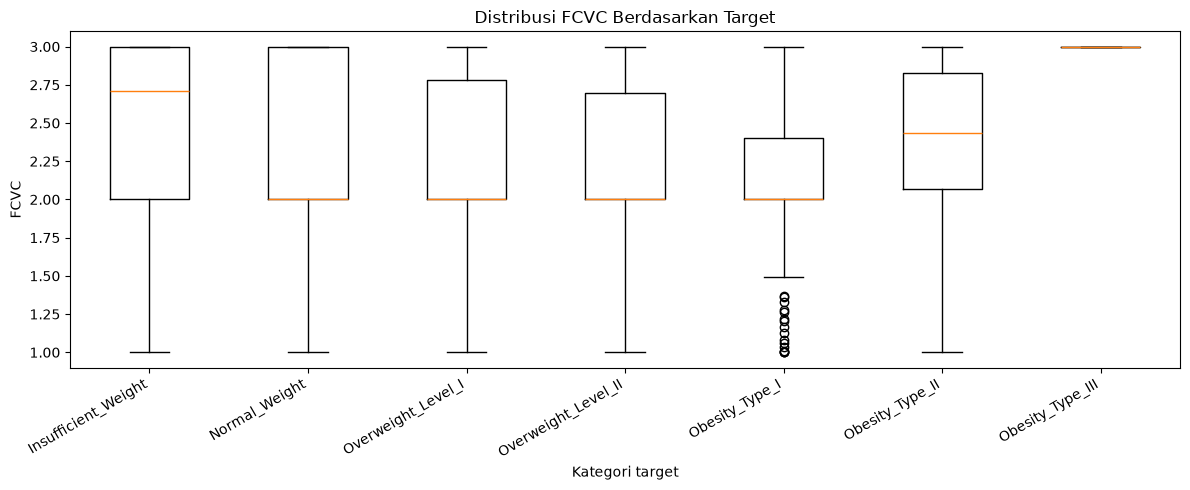

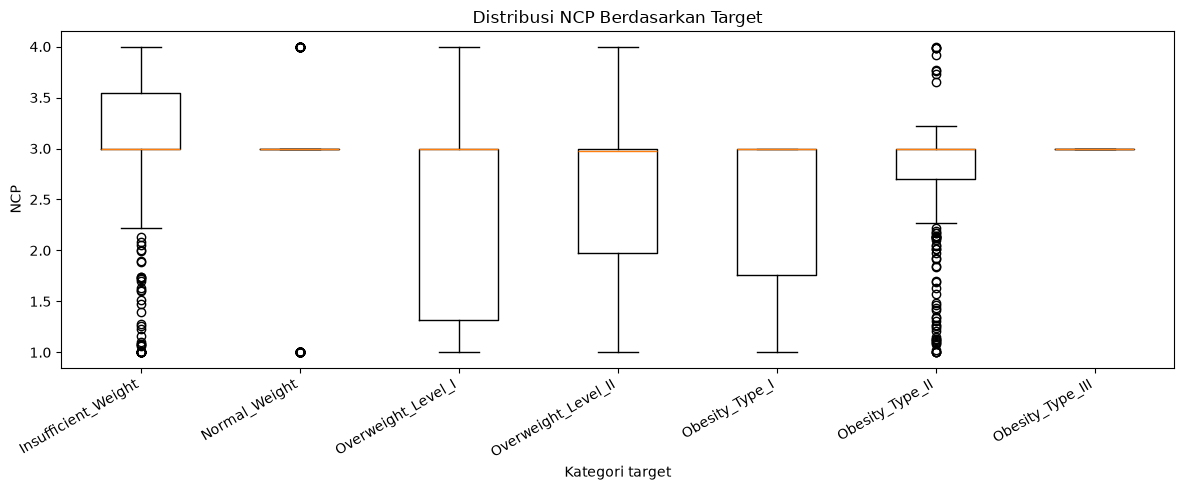

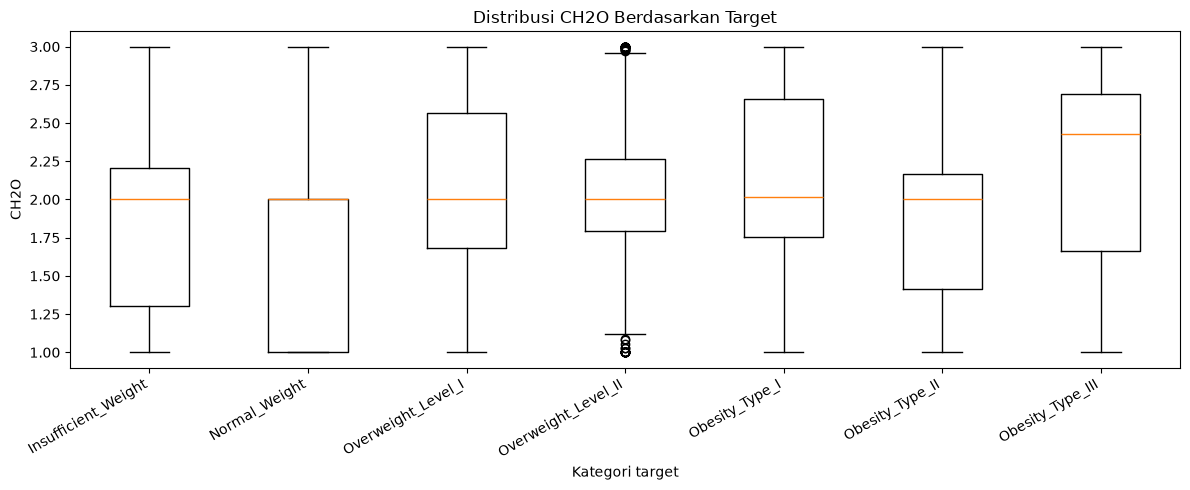

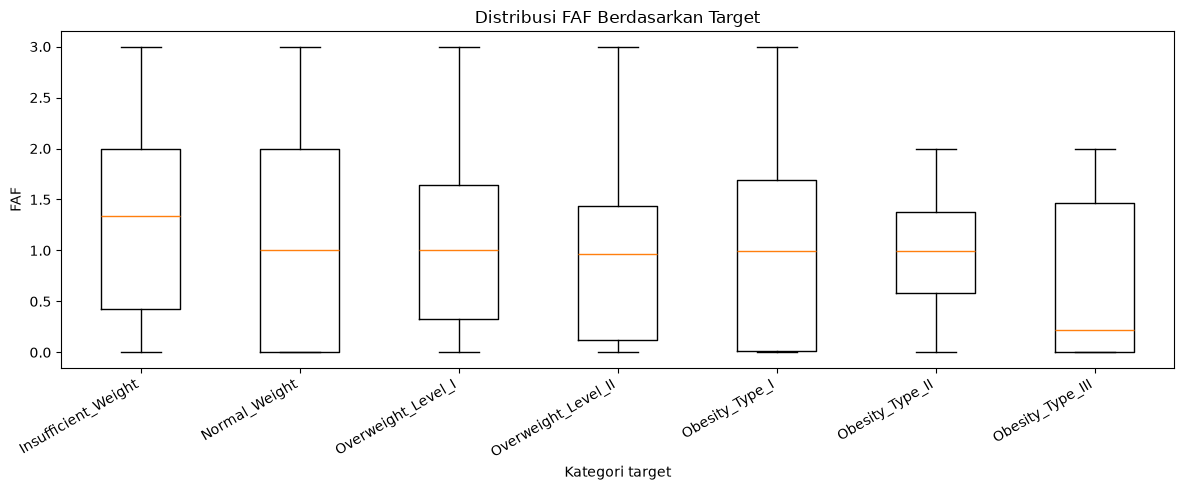

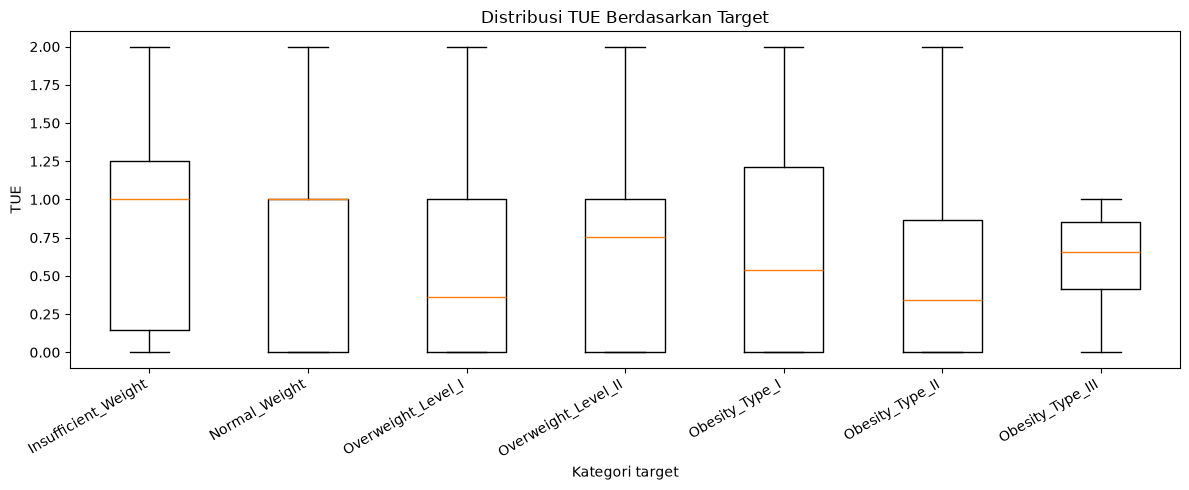

In [27]:
lifestyle_numeric_columns = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

for column in lifestyle_numeric_columns:
    group_data = [
        df_eda.loc[df_eda["NObeyesdad"] == category, column].dropna()
        for category in target_order
    ]

    plt.figure(figsize=(12, 5))
    plt.boxplot(
    group_data,
    tick_labels=target_order,
    vert=True
)
    plt.title(f"Distribusi {column} Berdasarkan Target")
    plt.xlabel("Kategori target")
    plt.ylabel(column)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 12. Hubungan fitur kategorikal dengan target asli

Crosstab dinormalisasi per kategori fitur. Setiap baris menunjukkan proporsi target di dalam kategori tersebut.



=== Proporsi target berdasarkan family_history_with_overweight ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
family_history_with_overweight,,,,,,,
no,37.920,34.290,21.040,4.680,1.820,0.260,0.000
yes,7.300,8.980,12.110,15.760,19.930,17.150,18.770


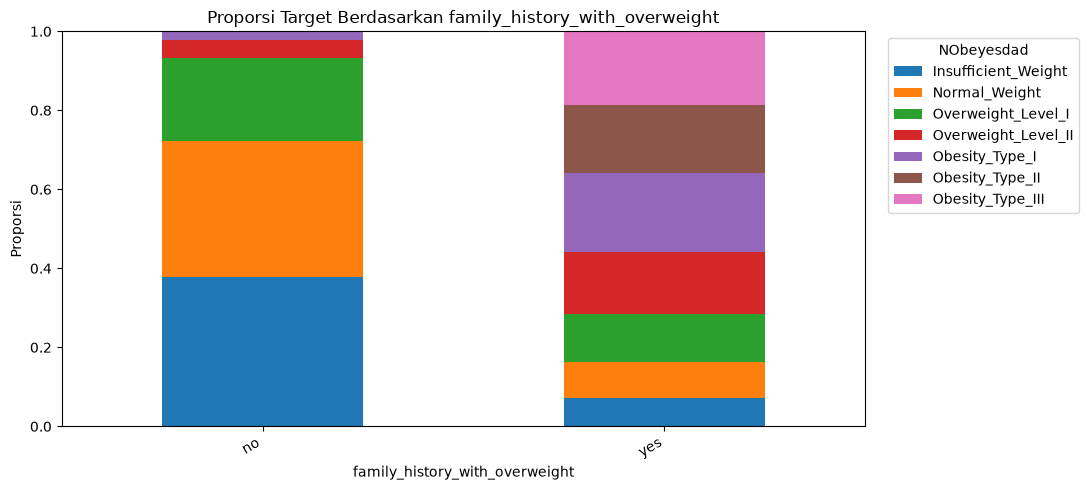


=== Proporsi target berdasarkan FAVC ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
FAVC,,,,,,,
no,20.820,32.240,8.980,30.200,4.490,2.860,0.410
yes,11.840,11.150,14.360,11.580,18.220,15.540,17.310


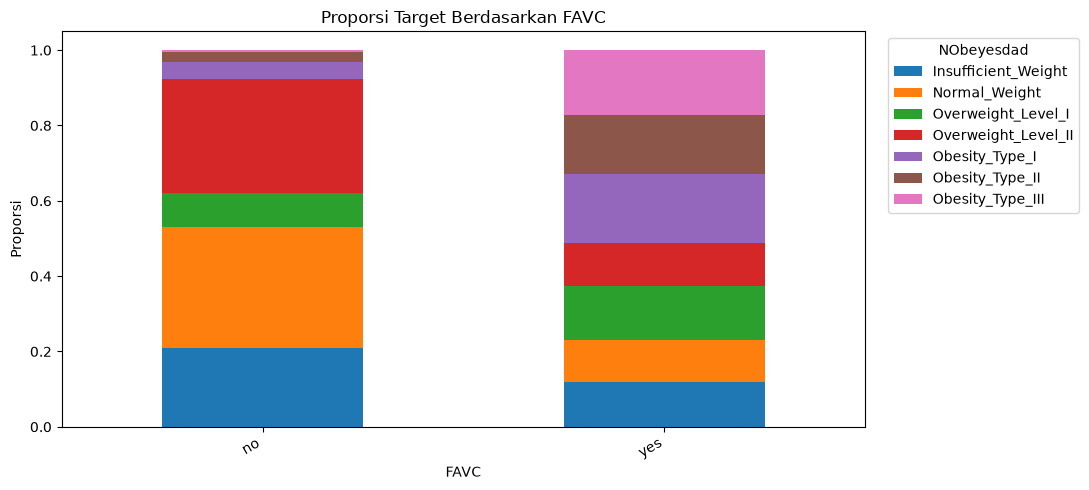


=== Proporsi target berdasarkan CAEC ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
CAEC,,,,,,,
Always,3.770,66.040,9.430,5.660,11.320,3.770,0.000
Frequently,50.000,34.300,5.790,6.610,2.480,0.410,0.410
Sometimes,8.270,9.010,13.370,15.300,19.150,16.600,18.300
no,5.880,19.610,68.630,1.960,1.960,1.960,0.000


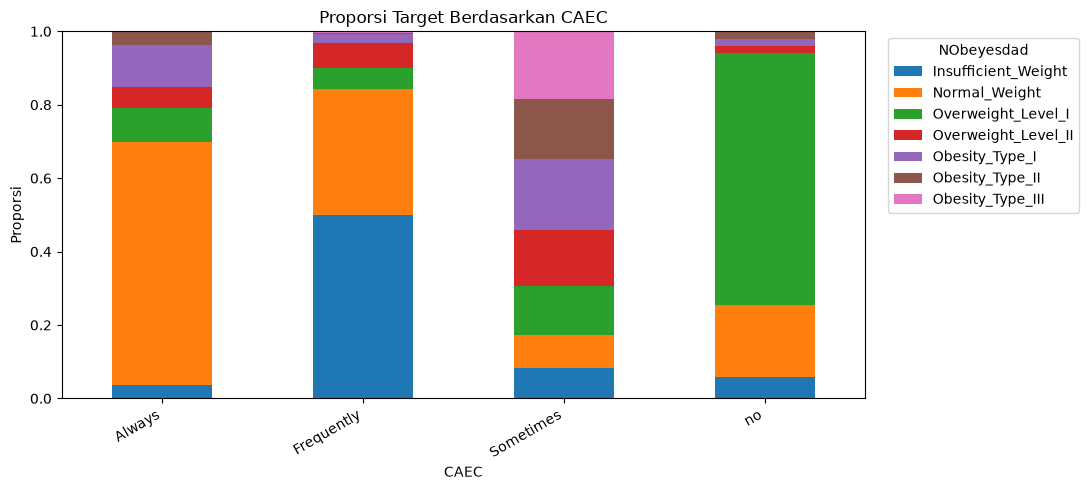


=== Proporsi target berdasarkan SCC ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
SCC,,,,,,,
no,12.410,12.750,12.560,14.190,17.320,14.690,16.080
yes,22.920,31.250,38.540,4.170,2.080,1.040,0.000


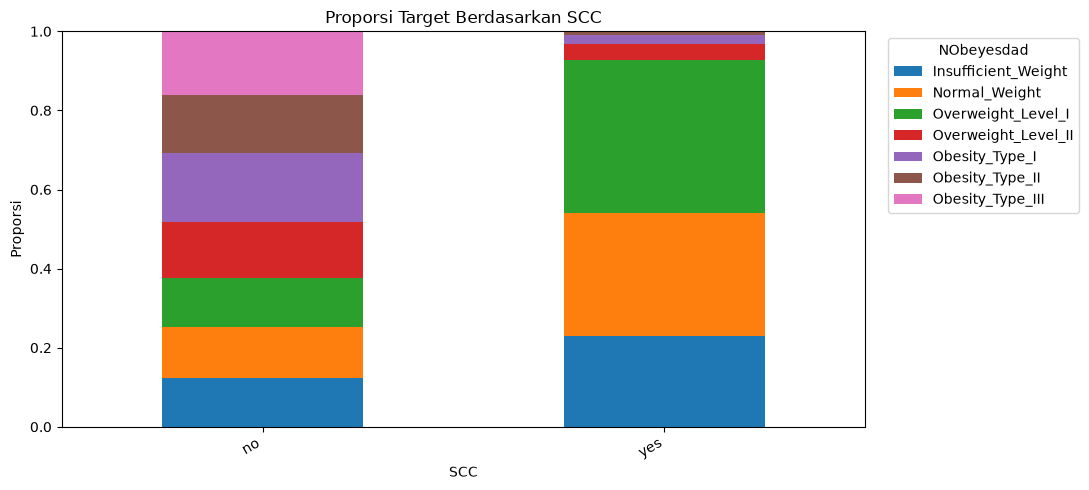


=== Proporsi target berdasarkan CALC ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
CALC,,,,,,,
Always,0.000,100.000,0.000,0.000,0.000,0.000,0.000
Frequently,1.430,25.710,22.860,27.140,20.000,2.860,0.000
Sometimes,10.990,11.490,15.990,10.210,12.280,15.990,23.050
no,18.310,16.740,7.820,20.030,25.820,11.110,0.160


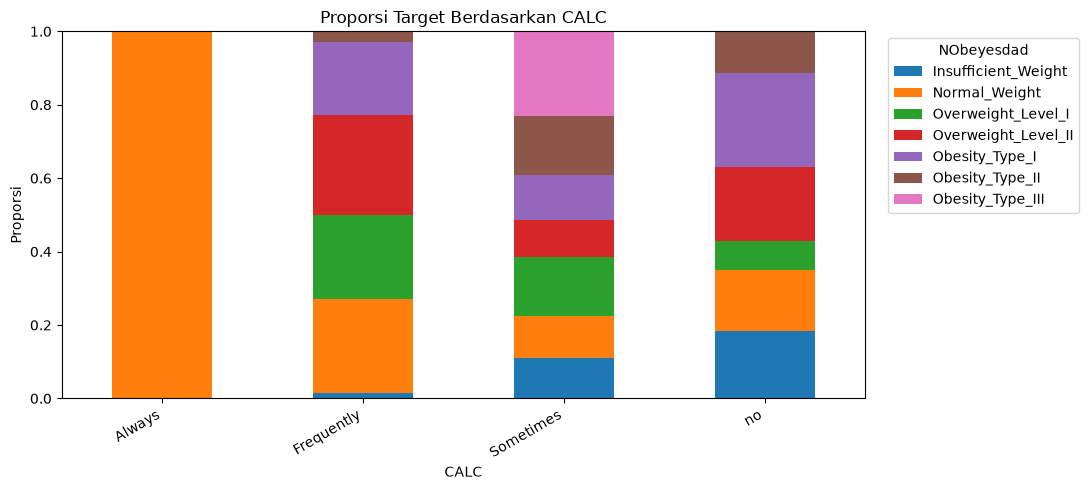


=== Proporsi target berdasarkan MTRANS ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
MTRANS,,,,,,,
Automobile,10.070,9.850,14.440,20.570,24.070,20.790,0.220
Bike,0.000,57.140,28.570,0.000,0.000,14.290,0.000
Motorbike,0.000,54.550,9.090,9.090,27.270,0.000,0.000
Public_Transportation,13.920,12.660,13.420,11.960,14.940,12.660,20.440
Walking,10.710,57.140,16.070,10.710,3.570,1.790,0.000


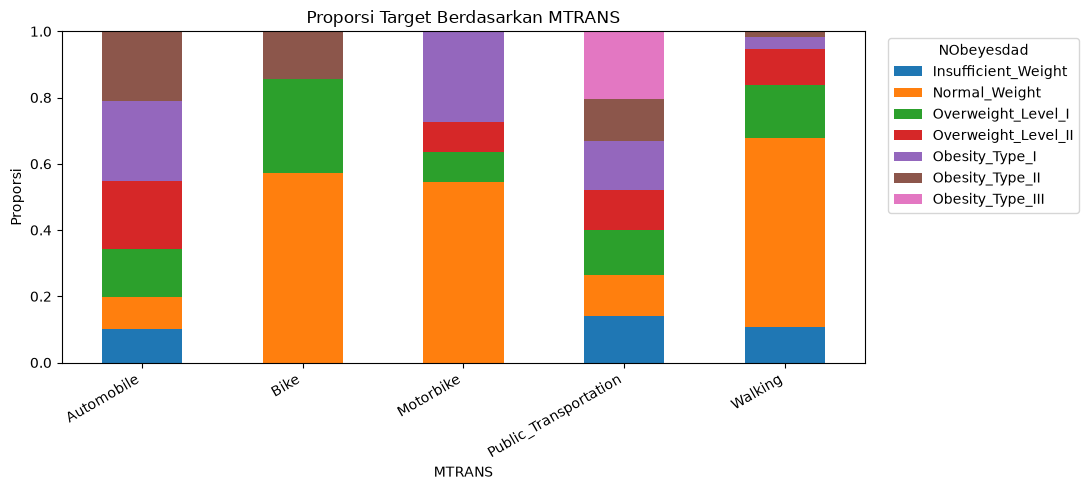


=== Proporsi target berdasarkan SMOKE ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
SMOKE,,,,,,,
no,13.110,13.260,13.880,13.790,16.690,13.640,15.630
yes,2.270,29.550,6.820,11.360,13.640,34.090,2.270


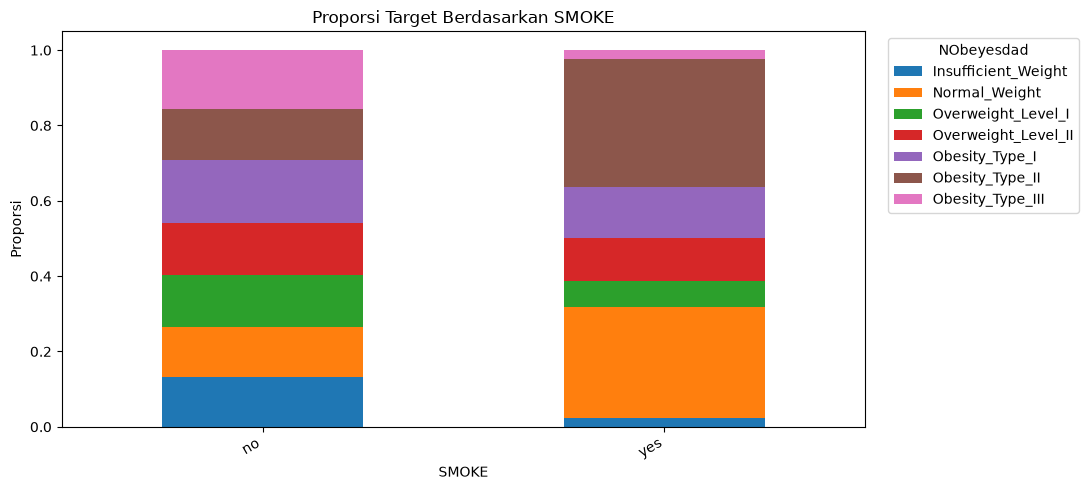


=== Proporsi target berdasarkan Gender ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
Gender,,,,,,,
Female,16.590,13.520,13.900,9.880,14.960,0.190,30.970
Male,9.270,13.670,13.580,17.510,18.260,27.620,0.090


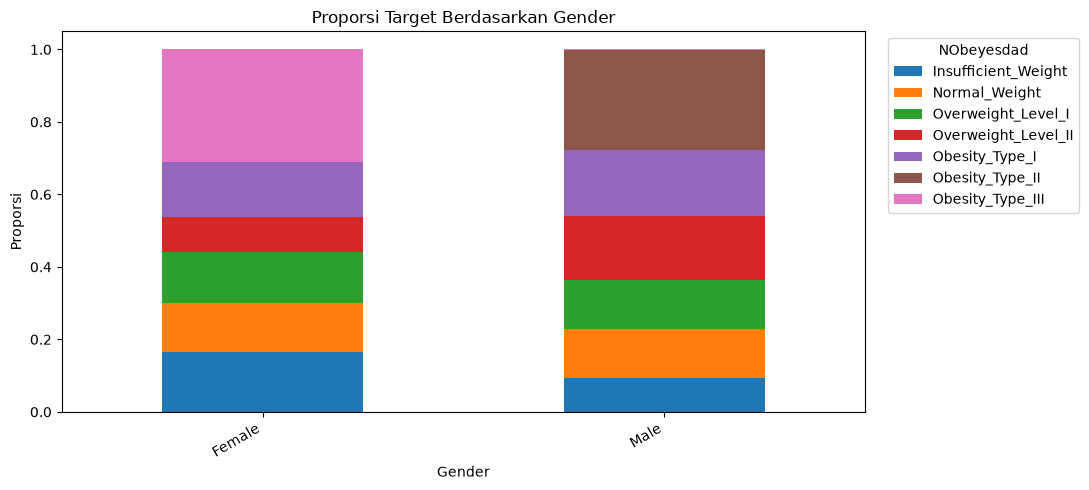

In [28]:
relationship_categorical_columns = [
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SCC",
    "CALC",
    "MTRANS",
    "SMOKE",
    "Gender",
]

for column in relationship_categorical_columns:
    table = pd.crosstab(
        df_eda[column],
        df_eda["NObeyesdad"],
        normalize="index",
    ).reindex(columns=target_order, fill_value=0)

    print(f"\n=== Proporsi target berdasarkan {column} ===")
    display((table * 100).round(2))

    plt.figure(figsize=(11, 5))
    table.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title(f"Proporsi Target Berdasarkan {column}")
    plt.xlabel(column)
    plt.ylabel("Proporsi")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="NObeyesdad", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## 13. Korelasi fitur numerik

Korelasi hanya menunjukkan hubungan linier dan tidak membuktikan hubungan sebab-akibat. Matriks ini digunakan sebagai eksplorasi awal, bukan dasar tunggal pemilihan fitur.


In [29]:
correlation_matrix = df_eda[numeric_columns + ["BMI_EDA"]].corr()
display(correlation_matrix.round(3))


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI_EDA
Age,1.000,-0.026,0.203,0.016,-0.044,-0.045,-0.145,-0.297,0.244
Height,-0.026,1.000,0.463,-0.038,0.244,0.213,0.295,0.052,0.132
Weight,0.203,0.463,1.000,0.216,0.107,0.201,-0.051,-0.072,0.935
FCVC,0.016,-0.038,0.216,1.000,0.042,0.068,0.020,-0.101,0.264
NCP,-0.044,0.244,0.107,0.042,1.000,0.057,0.130,0.036,0.040
CH2O,-0.045,0.213,0.201,0.068,0.057,1.000,0.167,0.012,0.144
FAF,-0.145,0.295,-0.051,0.020,0.130,0.167,1.000,0.059,-0.178
TUE,-0.297,0.052,-0.072,-0.101,0.036,0.012,0.059,1.000,-0.100
BMI_EDA,0.244,0.132,0.935,0.264,0.040,0.144,-0.178,-0.100,1.000


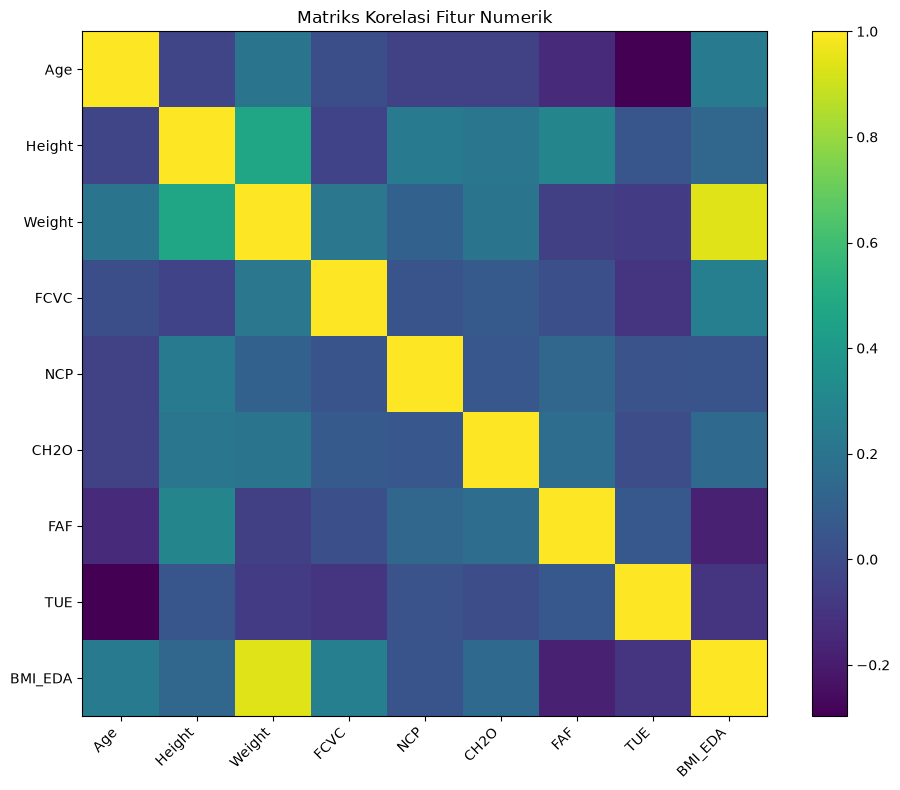

In [30]:
plt.figure(figsize=(10, 8))
image = plt.imshow(correlation_matrix)
plt.colorbar(image)
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index,
)
plt.title("Matriks Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()


## 14. Pratinjau target biner sesuai konsep project

Definisi awal:

- `Obesity_Type_I`, `Obesity_Type_II`, dan `Obesity_Type_III` → **Obesity**
- kategori lainnya → **Non-Obesity**

Target ini masih berupa pratinjau EDA. Pembuatan target final dilakukan pada notebook preprocessing agar seluruh keputusan terdokumentasi dengan jelas.


,count,percentage
Obesity_Binary,,
Non-Obesity,1139,53.960
Obesity,972,46.040


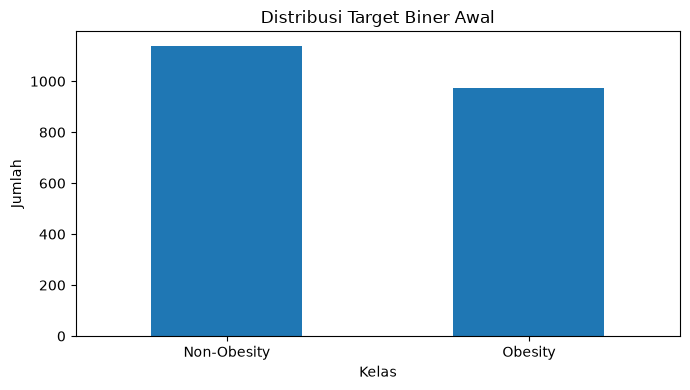

In [31]:
obesity_classes = {
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
}

df_eda["Obesity_Binary"] = np.where(
    df_eda["NObeyesdad"].isin(obesity_classes),
    "Obesity",
    "Non-Obesity",
)

binary_counts = df_eda["Obesity_Binary"].value_counts()
binary_percentages = (
    df_eda["Obesity_Binary"].value_counts(normalize=True) * 100
).round(2)

binary_summary = pd.DataFrame(
    {
        "count": binary_counts,
        "percentage": binary_percentages,
    }
)

display(binary_summary)

plt.figure(figsize=(7, 4))
binary_counts.plot(kind="bar")
plt.title("Distribusi Target Biner Awal")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [32]:
binary_numeric_summary = (
    df_eda.groupby("Obesity_Binary", observed=False)[
        ["Age", "FCVC", "NCP", "CH2O", "FAF", "TUE", "Height", "Weight", "BMI_EDA"]
    ]
    .mean()
    .round(3)
)

display(binary_numeric_summary)


,Age,FCVC,NCP,CH2O,FAF,TUE,Height,Weight,BMI_EDA
Obesity_Binary,,,,,,,,,
Non-Obesity,23.038,2.333,2.659,1.953,1.126,0.704,1.690,67.388,23.505
Obesity,25.806,2.520,2.717,2.073,0.875,0.603,1.716,109.082,36.960


In [33]:
binary_relationship_columns = [
    "FAVC",
    "CAEC",
    "SCC",
    "CALC",
    "MTRANS",
    "family_history_with_overweight",
    "Gender",
    "SMOKE",
]

for column in binary_relationship_columns:
    table = pd.crosstab(
        df_eda[column],
        df_eda["Obesity_Binary"],
        normalize="columns",
    )

    print(f"\n=== Distribusi {column} di dalam setiap kelas biner (%) ===")
    display((table * 100).round(2))



=== Distribusi FAVC di dalam setiap kelas biner (%) ===


Obesity_Binary,Non-Obesity,Obesity
FAVC,,
no,19.840,1.950
yes,80.160,98.050



=== Distribusi CAEC di dalam setiap kelas biner (%) ===


Obesity_Binary,Non-Obesity,Obesity
CAEC,,
Always,3.950,0.820
Frequently,20.540,0.820
Sometimes,71.200,98.150
no,4.300,0.210



=== Distribusi SCC di dalam setiap kelas biner (%) ===


...

Obesity_Binary,Non-Obesity,Obesity
family_history_with_overweight,,
no,33.100,0.820
yes,66.900,99.180



=== Distribusi Gender di dalam setiap kelas biner (%) ===


Obesity_Binary,Non-Obesity,Obesity
Gender,,
Female,49.340,49.490
Male,50.660,50.510



=== Distribusi SMOKE di dalam setiap kelas biner (%) ===


Obesity_Binary,Non-Obesity,Obesity
SMOKE,,
no,98.070,97.740
yes,1.930,2.260


## 15. Fitur kandidat sesuai ruang lingkup NutriSmart AI

Model utama direncanakan berfokus pada pola hidup.

### Kandidat fitur pola makan

- `FAVC`
- `FCVC`
- `NCP`
- `CAEC`
- `CH2O`
- `SCC`
- `CALC`

### Kandidat fitur aktivitas dan perilaku

- `FAF`
- `TUE`
- `MTRANS`
- `SMOKE` sebagai fitur opsional

### Tidak digunakan sebagai fitur utama model pola hidup

- `Height`
- `Weight`
- `BMI_EDA`

### Perlu diuji dalam eksperimen terpisah

- `Age`
- `Gender`
- `family_history_with_overweight`

Tiga variabel terakhir dapat meningkatkan performa, tetapi skor model tidak lagi murni menggambarkan pola hidup. Keputusan final akan ditentukan pada tahap feature selection.


In [34]:
candidate_lifestyle_features = [
    "FAVC",
    "FCVC",
    "NCP",
    "CAEC",
    "CH2O",
    "SCC",
    "FAF",
    "TUE",
    "CALC",
    "MTRANS",
]

optional_lifestyle_features = ["SMOKE"]

profile_features_for_experiment = [
    "Age",
    "Gender",
    "family_history_with_overweight",
]

excluded_from_lifestyle_model = [
    "Height",
    "Weight",
    "BMI_EDA",
]

feature_plan = pd.DataFrame(
    {
        "group": (
            ["Main lifestyle feature"] * len(candidate_lifestyle_features)
            + ["Optional lifestyle feature"] * len(optional_lifestyle_features)
            + ["Separate experiment"] * len(profile_features_for_experiment)
            + ["Excluded from lifestyle model"] * len(excluded_from_lifestyle_model)
        ),
        "feature": (
            candidate_lifestyle_features
            + optional_lifestyle_features
            + profile_features_for_experiment
            + excluded_from_lifestyle_model
        ),
    }
)

display(feature_plan)


,group,feature
0,Main lifestyle feature,FAVC
1,Main lifestyle feature,FCVC
2,Main lifestyle feature,NCP
3,Main lifestyle feature,CAEC
4,Main lifestyle feature,CH2O
5,Main lifestyle feature,SCC
6,Main lifestyle feature,FAF
7,Main lifestyle feature,TUE
8,Main lifestyle feature,CALC
9,Main lifestyle feature,MTRANS


## 16. Ringkasan otomatis hasil EDA

Cell berikut menyusun ringkasan angka utama yang dapat digunakan saat menulis laporan.


In [35]:
eda_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "missing_values": int(df.isna().sum().sum()),
    "full_duplicates": int(df.duplicated().sum()),
    "numeric_columns": len(numeric_columns),
    "categorical_columns": len(categorical_columns),
    "original_target_classes": int(df["NObeyesdad"].nunique()),
    "binary_obesity_count": int(
        (df_eda["Obesity_Binary"] == "Obesity").sum()
    ),
    "binary_non_obesity_count": int(
        (df_eda["Obesity_Binary"] == "Non-Obesity").sum()
    ),
}

display(pd.Series(eda_summary, name="value").to_frame())


,value
rows,2111
columns,17
missing_values,0
full_duplicates,24
numeric_columns,8
categorical_columns,9
original_target_classes,7
binary_obesity_count,972
binary_non_obesity_count,1139


## 17. Kesimpulan EDA

Berdasarkan eksplorasi awal:

1. Dataset memiliki **2.111 baris dan 17 kolom**.
2. Dataset tidak memiliki missing value.
3. Terdapat sejumlah baris duplikat penuh yang harus dihapus pada preprocessing.
4. Target asli terdiri dari tujuh kelas dan distribusinya relatif seimbang.
5. Dataset memiliki kombinasi fitur numerik dan kategorikal.
6. Sejumlah fitur kategorikal memiliki kategori yang sangat jarang.
7. Nilai desimal pada beberapa fitur ordinal berkaitan dengan proses pembentukan data sintetik.
8. Tinggi dan berat badan sangat terkait dengan label target karena membentuk BMI.
9. Memasukkan tinggi, berat, atau BMI ke model akan berisiko membuat model lebih banyak membaca status tubuh daripada pola hidup.
10. Untuk konsep NutriSmart AI, model utama akan diprioritaskan menggunakan pola makan, aktivitas fisik, screen time, dan transportasi.
11. Target biner awal memiliki dua kelas yang cukup seimbang untuk eksperimen klasifikasi.
12. Dataset sesuai untuk final project, tetapi keterbatasan data sintetik dan perbedaan populasi harus dijelaskan dalam laporan.

## Keputusan menuju notebook berikutnya

Pada `02_preprocessing_feature_selection.ipynb`, kita akan:

1. Menghapus duplikat.
2. Membuat target biner final.
3. Memisahkan fitur dan target.
4. Membuat dua skenario fitur:
   - pola hidup saja;
   - pola hidup ditambah profil dasar.
5. Menentukan preprocessing numerik dan kategorikal.
6. Membagi data training dan testing secara stratified.
7. Menyimpan data bersih dan keputusan preprocessing.


## 18. Checklist notebook

Pastikan sebelum melanjutkan:

- [ ] Seluruh cell berhasil dijalankan tanpa error.
- [ ] Dataset terbaca dari `data/raw/`.
- [ ] Jumlah missing value telah diperiksa.
- [ ] Duplikat telah diidentifikasi, tetapi dataset mentah belum diubah.
- [ ] Distribusi target telah dipahami.
- [ ] Hubungan BMI dan target telah dipahami sebagai potensi leakage.
- [ ] Kandidat fitur pola hidup telah disepakati.
- [ ] Kesimpulan EDA telah dicatat untuk laporan.
